# Tesla Production Forecasting — End-to-End ML Pipeline

Building a complete pipeline on Tesla sales/production data:
preprocessing, EDA, feature engineering, regression, tuning, and forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
palette = sns.color_palette('viridis', 10)

## 1. Preprocessing

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.info()
print()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates: 0


In [5]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Regions: {df['Region'].unique()}")
print(f"Models: {df['Model'].unique()}")

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Regions: ['Asia' 'Middle East' 'North America' 'Europe']
Models: ['Model Y' 'Model 3' 'Cybertruck' 'Model S' 'Model X']


In [6]:
# outlier check (IQR) — reporting only
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n > 0:
        print(f"{col}: {n} outliers ({n/len(df)*100:.1f}%)")

Estimated_Deliveries: 12 outliers (0.5%)
Production_Units: 12 outliers (0.5%)
CO2_Saved_tons: 45 outliers (1.7%)


## 2. Exploratory Data Analysis

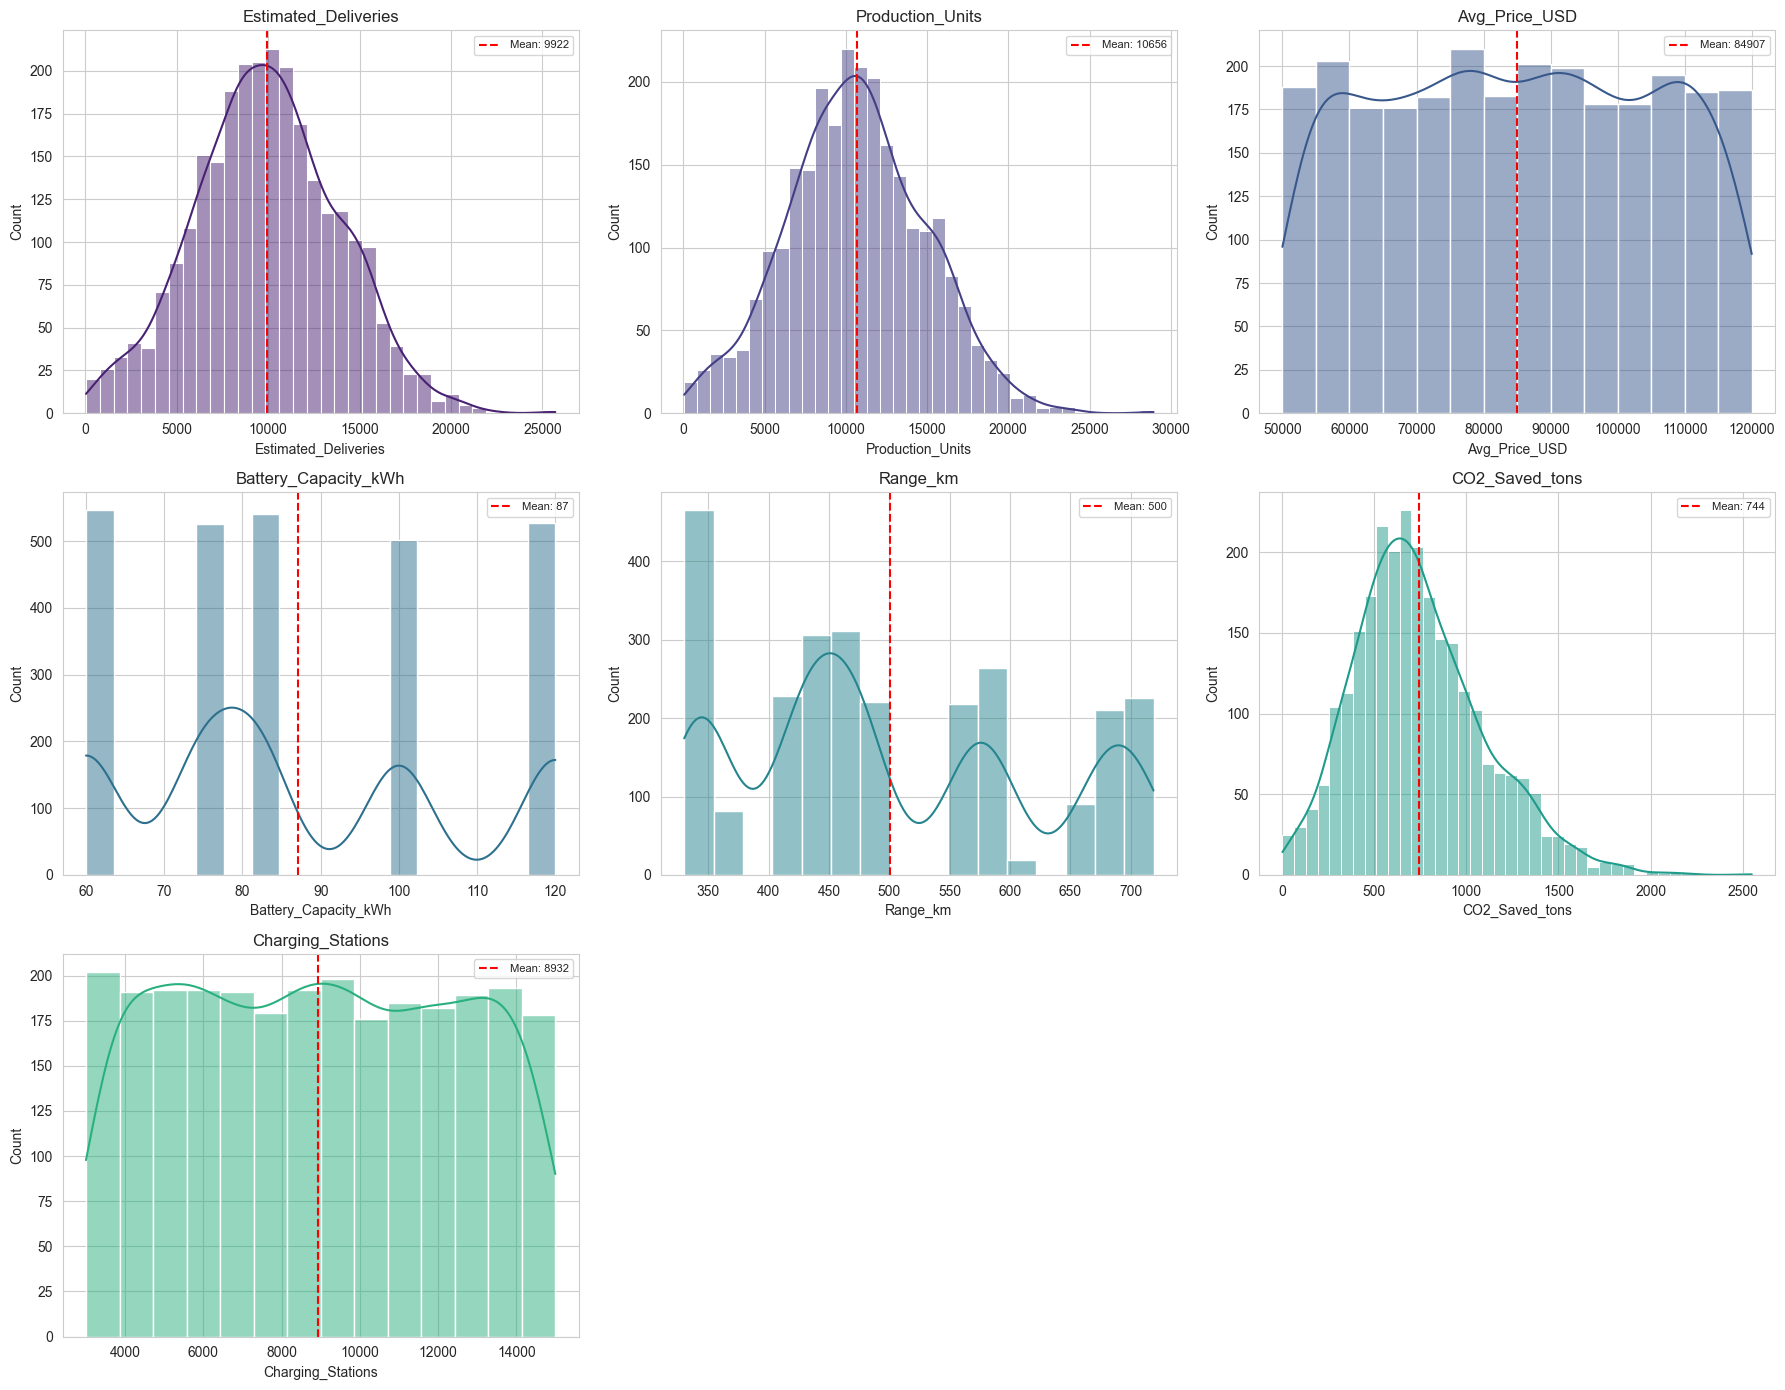

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=palette[i], edgecolor='white')
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[i].legend(fontsize=8)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

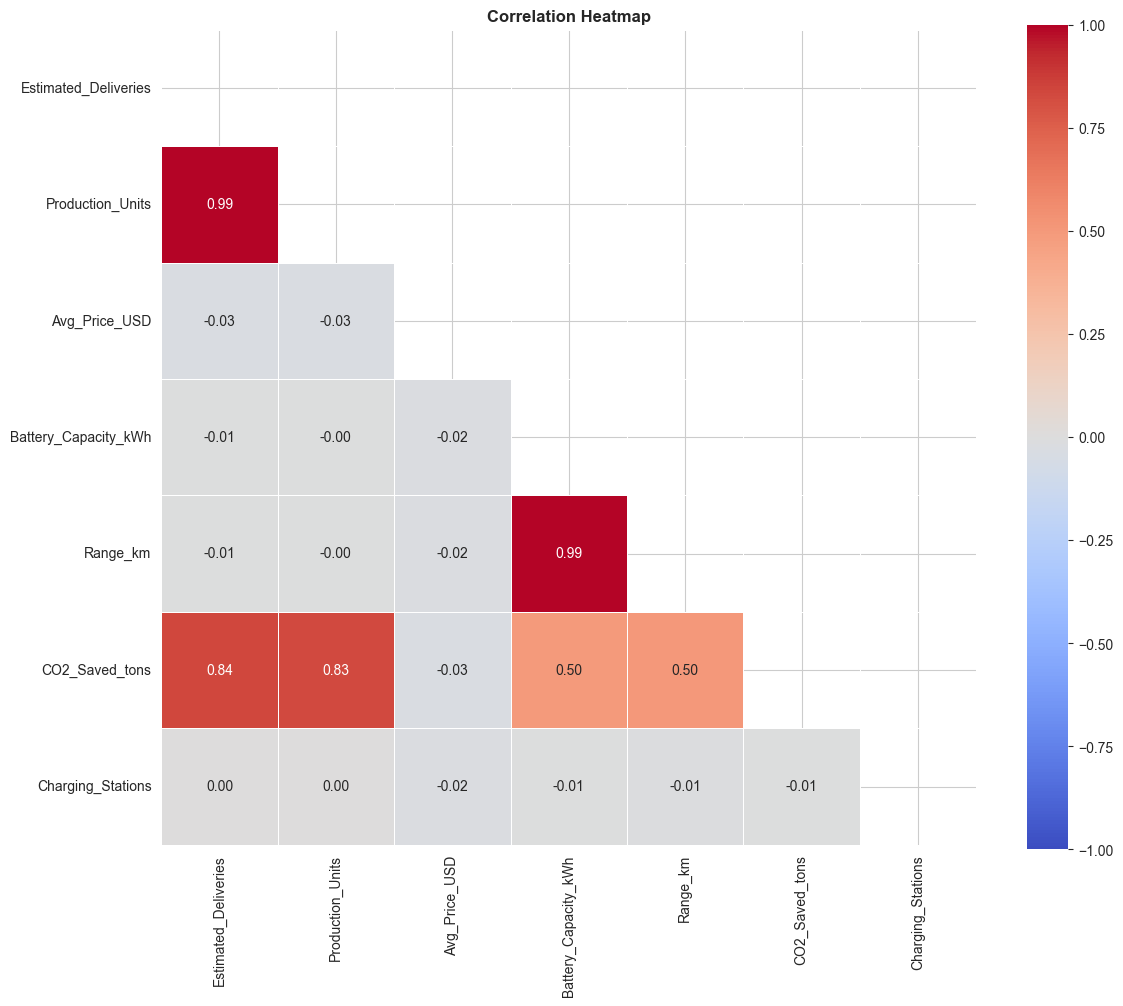

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

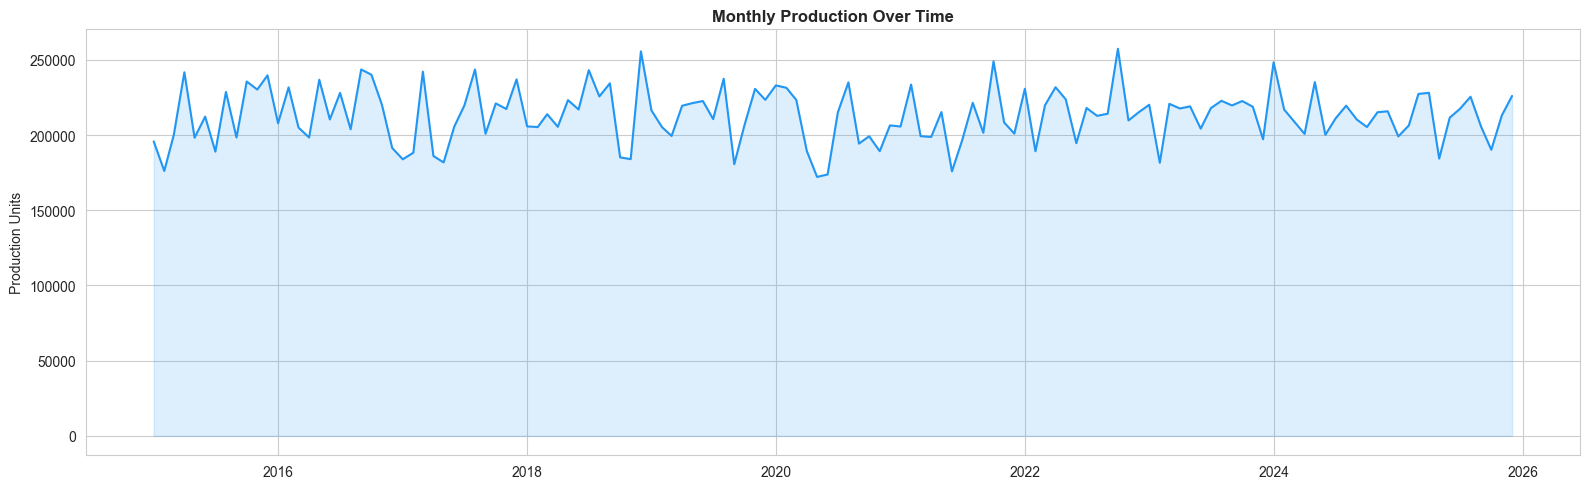

In [9]:
monthly = df.groupby('Date')['Production_Units'].sum().reset_index()
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['Date'], monthly['Production_Units'], color='#2196F3', linewidth=1.5)
ax.fill_between(monthly['Date'], monthly['Production_Units'], alpha=0.15, color='#2196F3')
ax.set_title('Monthly Production Over Time', fontweight='bold')
ax.set_ylabel('Production Units')
plt.tight_layout()
plt.show()

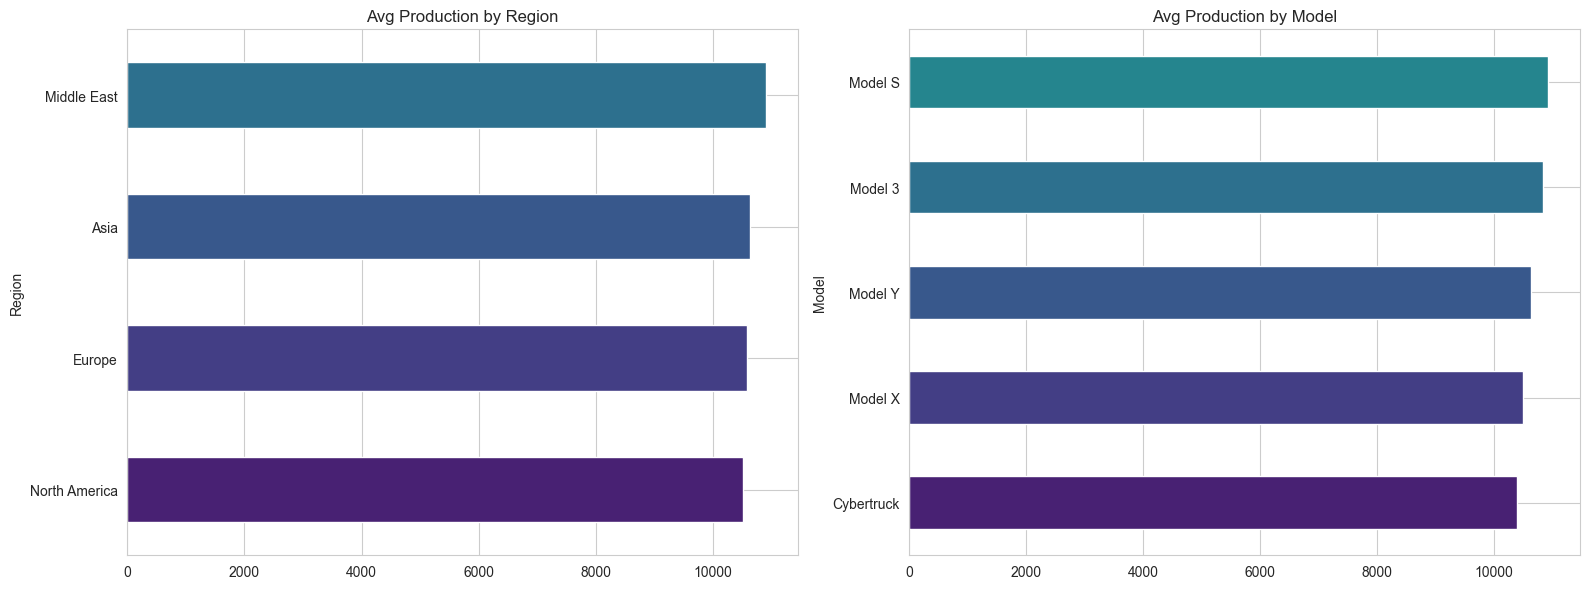

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.groupby('Region')['Production_Units'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color=palette[:4], edgecolor='white')
axes[0].set_title('Avg Production by Region')

df.groupby('Model')['Production_Units'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color=palette[:5], edgecolor='white')
axes[1].set_title('Avg Production by Model')
plt.tight_layout()
plt.show()

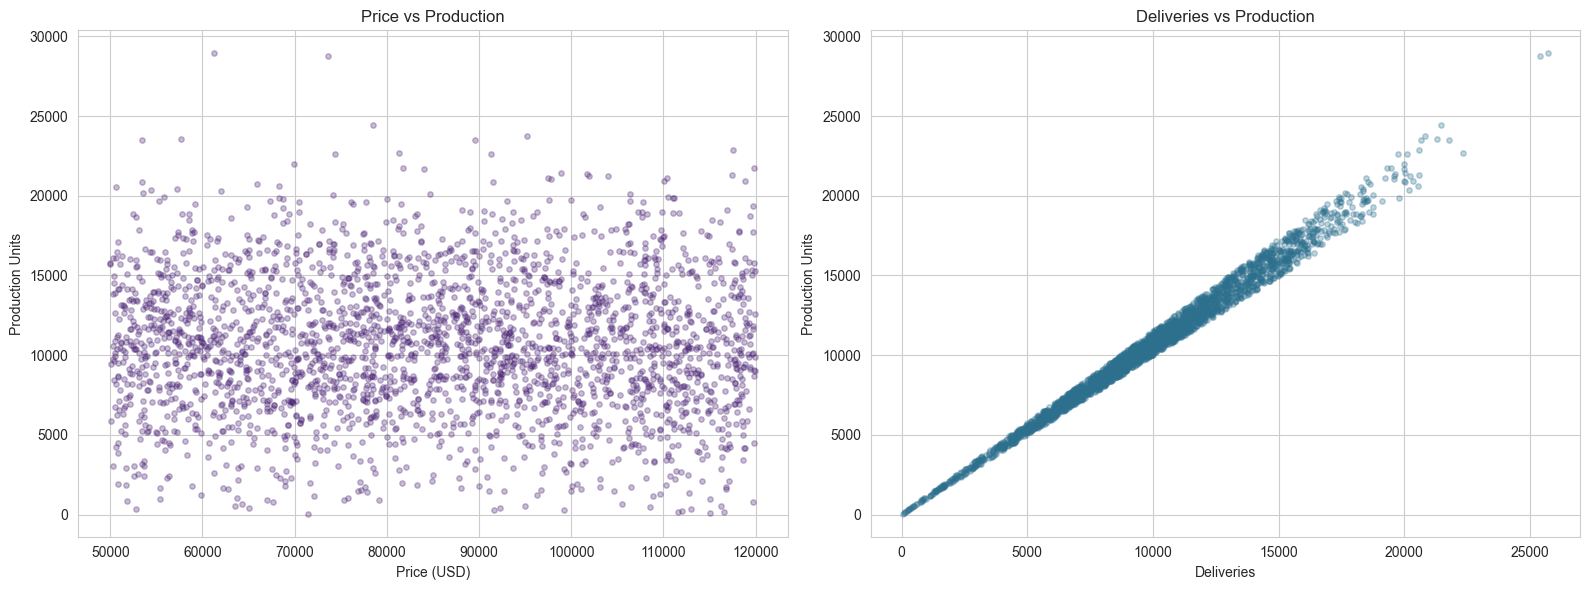

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(df['Avg_Price_USD'], df['Production_Units'], alpha=0.3, s=15, c=palette[0])
axes[0].set_title('Price vs Production')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Production Units')

axes[1].scatter(df['Estimated_Deliveries'], df['Production_Units'], alpha=0.3, s=15, c=palette[3])
axes[1].set_title('Deliveries vs Production')
axes[1].set_xlabel('Deliveries')
axes[1].set_ylabel('Production Units')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [12]:
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']
df['Price_per_Range'] = df['Avg_Price_USD'] / df['Range_km']
df['CO2_per_Delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']
df['Quarter'] = df['Month'].apply(lambda m: (m - 1) // 3 + 1)
df['Is_Year_End'] = df['Month'].isin([11, 12]).astype(int)

for lag in [1, 3, 12]:
    df[f'Production_Lag{lag}'] = df.groupby(['Region', 'Model'])['Production_Units'].shift(lag)

for w in [3, 12]:
    df[f'Production_Rolling{w}'] = (
        df.groupby(['Region', 'Model'])['Production_Units']
        .transform(lambda x: x.rolling(w, min_periods=1).mean())
    )

df_model = df.dropna().copy()
print(f"Shape after feature engineering: {df_model.shape}")
print(f"New features: Production_Efficiency, Price_per_kWh, Price_per_Range, "
      f"CO2_per_Delivery, Quarter, Is_Year_End, Lag1/3/12, Rolling3/12")

Shape after feature engineering: (2400, 24)
New features: Production_Efficiency, Price_per_kWh, Price_per_Range, CO2_per_Delivery, Quarter, Is_Year_End, Lag1/3/12, Rolling3/12


## 4. Regression Modeling

Target: `Production_Units`. Using sklearn Pipeline with ColumnTransformer
so preprocessing is bundled properly. Scaling only for the linear model.

In [13]:
target = 'Production_Units'

feature_cols = ['Year', 'Month', 'Estimated_Deliveries', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
                'Production_Efficiency', 'Price_per_kWh', 'Price_per_Range',
                'CO2_per_Delivery', 'Quarter', 'Is_Year_End',
                'Production_Lag1', 'Production_Lag3', 'Production_Lag12',
                'Production_Rolling3', 'Production_Rolling12',
                'Region', 'Model', 'Source_Type']

numeric_features = [c for c in feature_cols if c not in ['Region', 'Model', 'Source_Type']]
cat_onehot = ['Region', 'Model']
cat_ordinal = ['Source_Type']

X = df_model[feature_cols].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1920, 22), Test: (480, 22)


In [14]:
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_onehot),
    ('cat_ord', OrdinalEncoder(categories=[['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']]), cat_ordinal)
], remainder='drop')

preprocessor_passthrough = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_onehot),
    ('cat_ord', OrdinalEncoder(categories=[['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']]), cat_ordinal)
], remainder='drop')

pipelines = {
    'Linear Regression': Pipeline([('preprocessor', preprocessor_scaled), ('model', LinearRegression())]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor_passthrough), ('model', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor_passthrough), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline([('preprocessor', preprocessor_passthrough), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor_passthrough), ('model', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))])
}

In [15]:
results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)})
    print(f"{name:>20s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n", results_df.to_string(index=False))

   Linear Regression  MAE=119.74  RMSE=169.56  R2=0.9982
       Decision Tree  MAE=140.40  RMSE=197.22  R2=0.9976
       Random Forest  MAE=78.67  RMSE=115.10  R2=0.9992
   Gradient Boosting  MAE=70.87  RMSE=91.33  R2=0.9995
             XGBoost  MAE=87.52  RMSE=130.37  R2=0.9990

             Model    MAE   RMSE     R2
Gradient Boosting  70.87  91.33 0.9995
    Random Forest  78.67 115.10 0.9992
          XGBoost  87.52 130.37 0.9990
Linear Regression 119.74 169.56 0.9982
    Decision Tree 140.40 197.22 0.9976


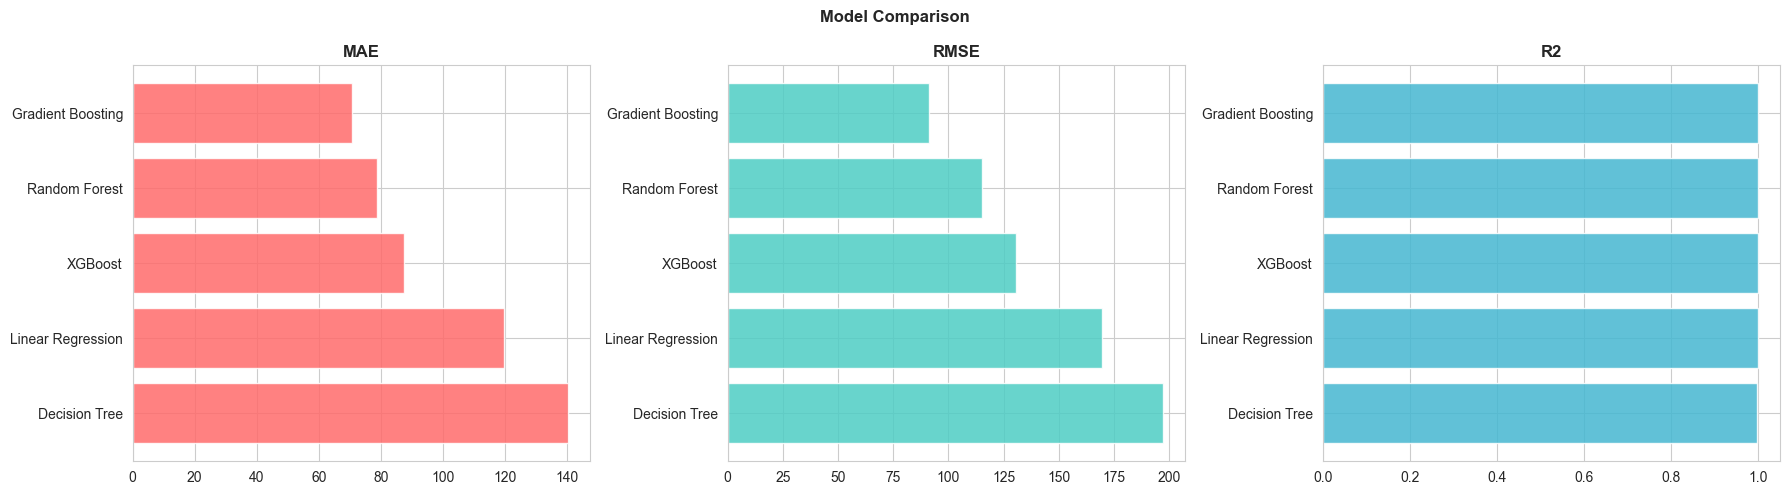

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    axes[i].barh(results_df['Model'], results_df[metric],
                 color=['#FF6B6B', '#4ECDC4', '#45B7D1'][i], edgecolor='white', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].invert_yaxis()
plt.suptitle('Model Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

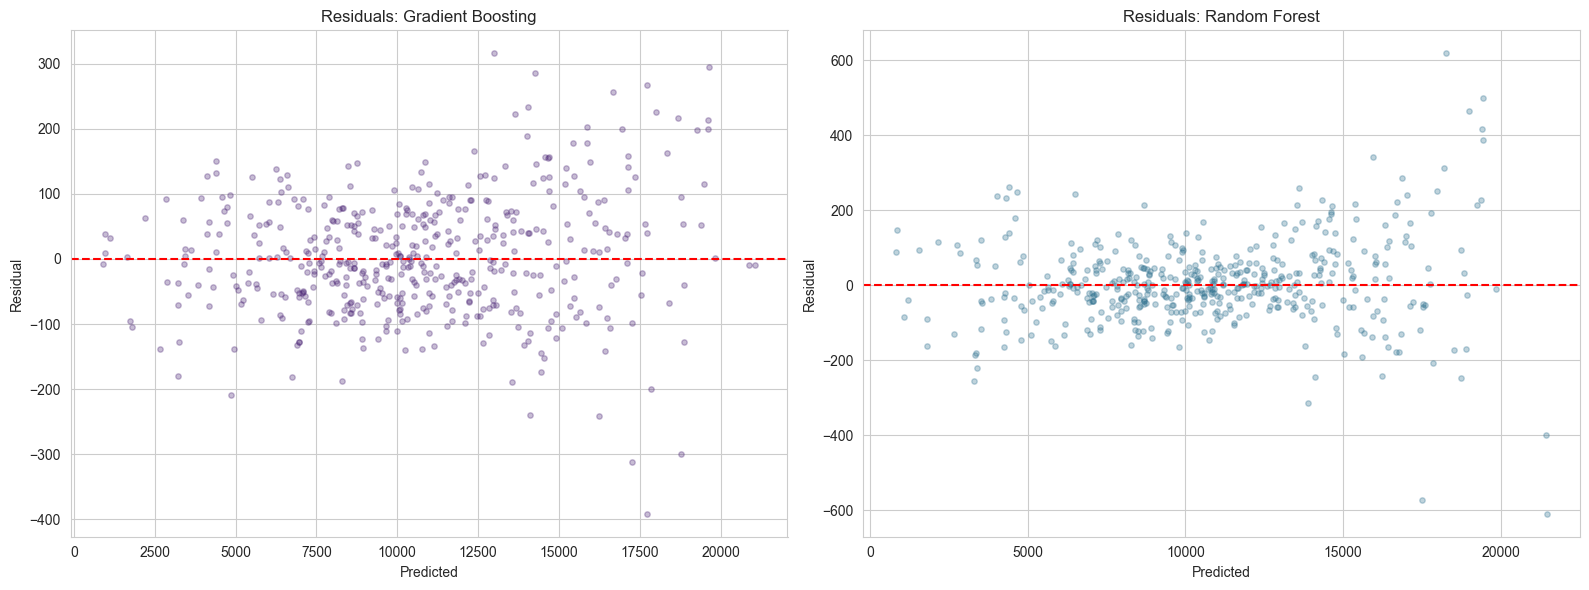

In [17]:
top2 = results_df.head(2)['Model'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, name in enumerate(top2):
    resid = y_test - pipelines[name].predict(X_test)
    axes[i].scatter(pipelines[name].predict(X_test), resid, alpha=0.3, s=15, color=palette[i*3])
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Residuals: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

In [18]:
# GridSearchCV on Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', RandomForestRegressor(random_state=42))
])

rf_grid = GridSearchCV(rf_pipe, {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}, cv=5, scoring='neg_mean_squared_error', verbose=0)
rf_grid.fit(X_train, y_train)

rf_tuned_pred = rf_grid.predict(X_test)
print(f"RF best params: {rf_grid.best_params_}")
print(f"RF tuned — RMSE={np.sqrt(mean_squared_error(y_test, rf_tuned_pred)):.2f}, R2={r2_score(y_test, rf_tuned_pred):.4f}")

RF best params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}
RF tuned — RMSE=115.10, R2=0.9992


In [19]:
# RandomizedSearchCV on XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', XGBRegressor(random_state=42, verbosity=0))
])

xgb_random = RandomizedSearchCV(xgb_pipe, {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}, n_iter=30, cv=5, scoring='neg_mean_squared_error', random_state=42, verbose=0)
xgb_random.fit(X_train, y_train)

xgb_tuned_pred = xgb_random.predict(X_test)
print(f"XGB best params: {xgb_random.best_params_}")
print(f"XGB tuned — RMSE={np.sqrt(mean_squared_error(y_test, xgb_tuned_pred)):.2f}, R2={r2_score(y_test, xgb_tuned_pred):.4f}")

XGB best params: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
XGB tuned — RMSE=138.27, R2=0.9988


In [20]:
# compare tuned vs untuned
comparison = pd.DataFrame([
    {'Model': 'RF (Untuned)', 'RMSE': results_df[results_df['Model']=='Random Forest']['RMSE'].values[0],
     'R2': results_df[results_df['Model']=='Random Forest']['R2'].values[0]},
    {'Model': 'RF (Tuned)', 'RMSE': round(np.sqrt(mean_squared_error(y_test, rf_tuned_pred)), 2),
     'R2': round(r2_score(y_test, rf_tuned_pred), 4)},
    {'Model': 'XGB (Untuned)', 'RMSE': results_df[results_df['Model']=='XGBoost']['RMSE'].values[0],
     'R2': results_df[results_df['Model']=='XGBoost']['R2'].values[0]},
    {'Model': 'XGB (Tuned)', 'RMSE': round(np.sqrt(mean_squared_error(y_test, xgb_tuned_pred)), 2),
     'R2': round(r2_score(y_test, xgb_tuned_pred), 4)},
])
print(comparison.to_string(index=False))

        Model   RMSE     R2
 RF (Untuned) 115.10 0.9992
   RF (Tuned) 115.10 0.9992
XGB (Untuned) 130.37 0.9990
  XGB (Tuned) 138.27 0.9988


## 6. Time Series Forecasting (SARIMAX)

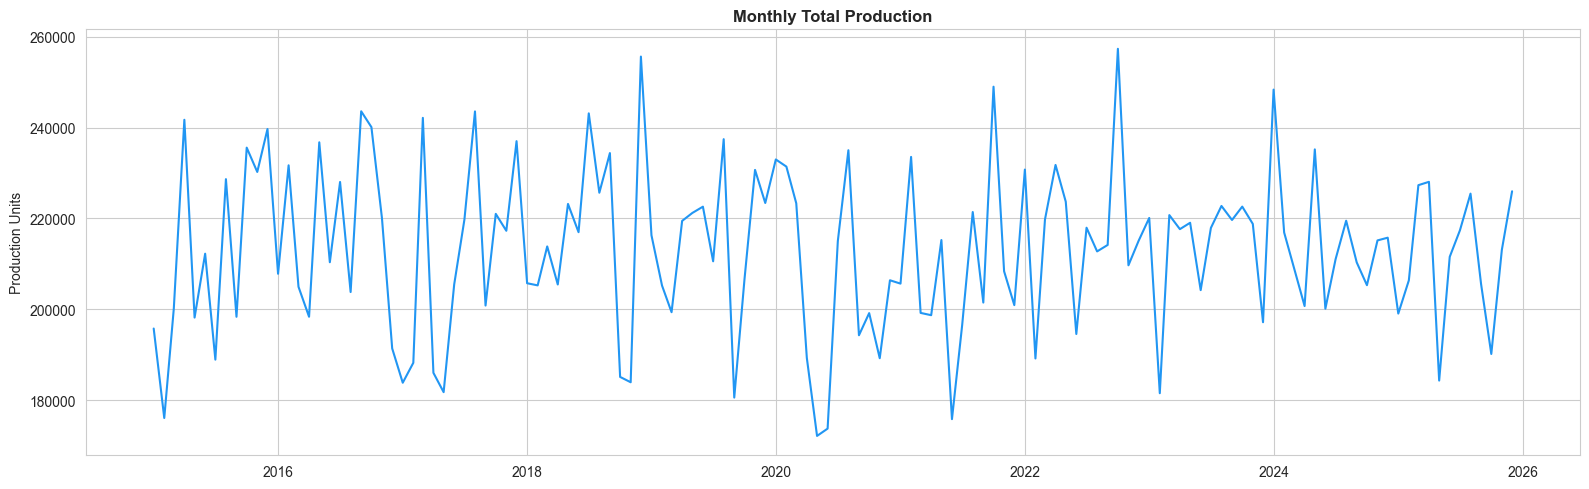

Length: 132 months


In [21]:
ts_data = df.groupby('Date')['Production_Units'].sum().asfreq('MS')
ts_data = ts_data.ffill()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_data, color='#2196F3', linewidth=1.5)
ax.set_title('Monthly Total Production', fontweight='bold')
ax.set_ylabel('Production Units')
plt.tight_layout()
plt.show()
print(f"Length: {len(ts_data)} months")

In [22]:
adf = adfuller(ts_data.dropna())
print(f"ADF stat: {adf[0]:.4f}, p-value: {adf[1]:.4f}")
print(f"Result: {'Stationary' if adf[1] < 0.05 else 'Non-stationary'}")

ADF stat: -8.9688, p-value: 0.0000
Result: Stationary


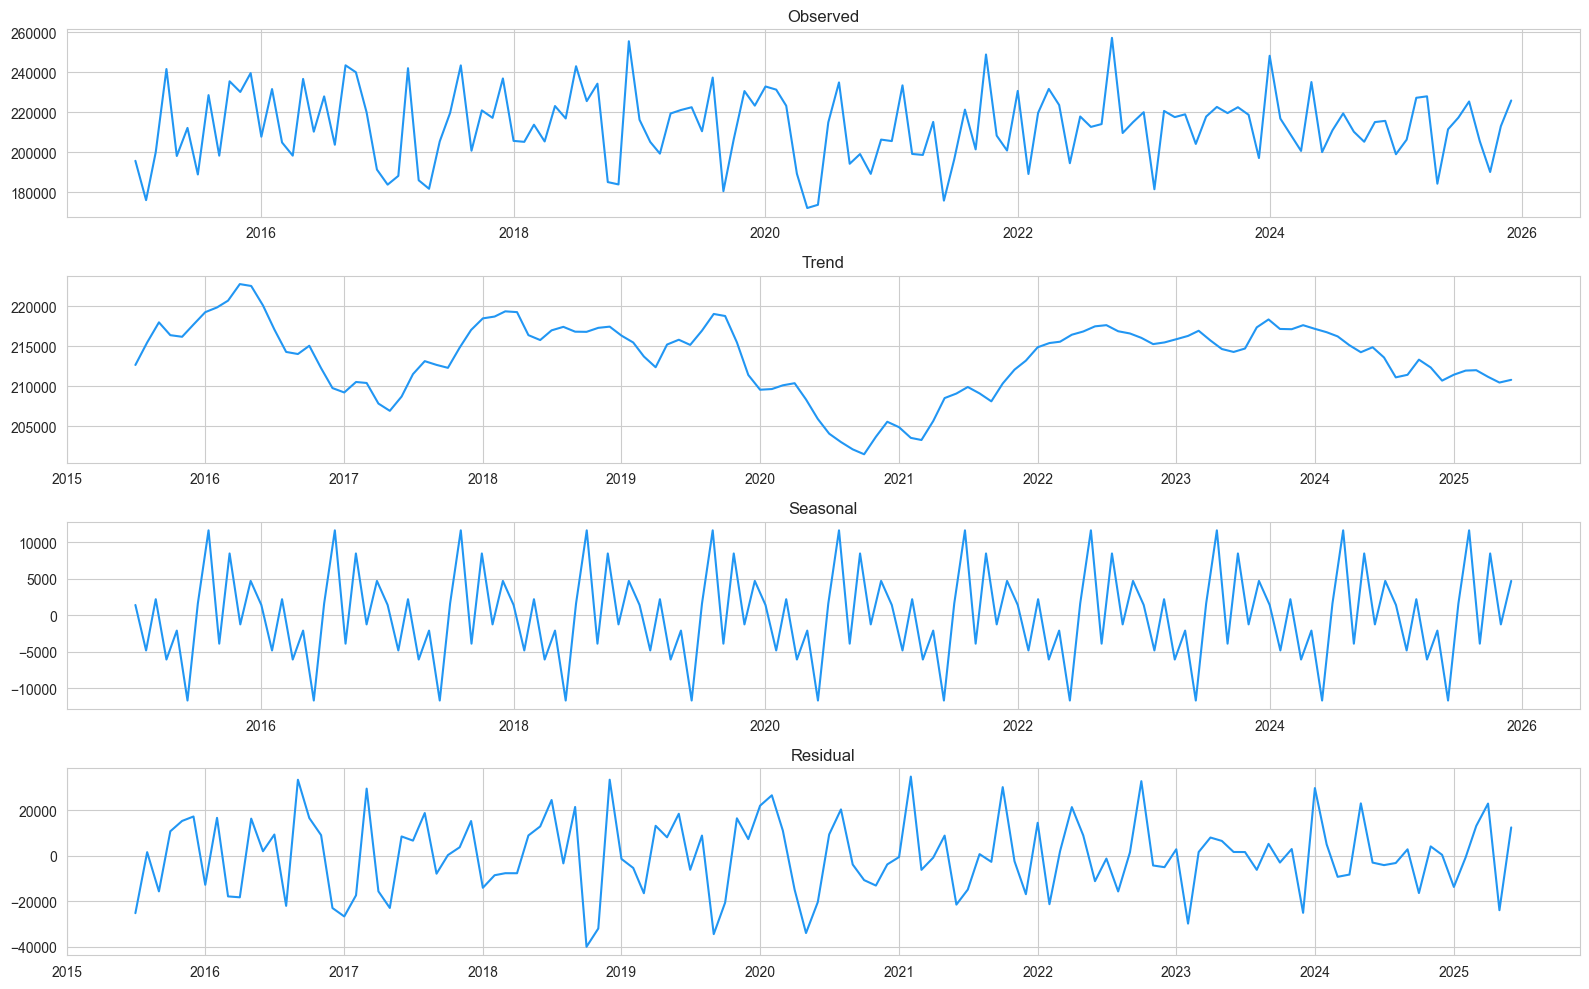

In [23]:
decomp = seasonal_decompose(ts_data, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(16, 10))
for ax, title, data in zip(axes, ['Observed', 'Trend', 'Seasonal', 'Residual'],
                            [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]):
    ax.plot(data, color='#2196F3')
    ax.set_title(title)
plt.tight_layout()
plt.show()

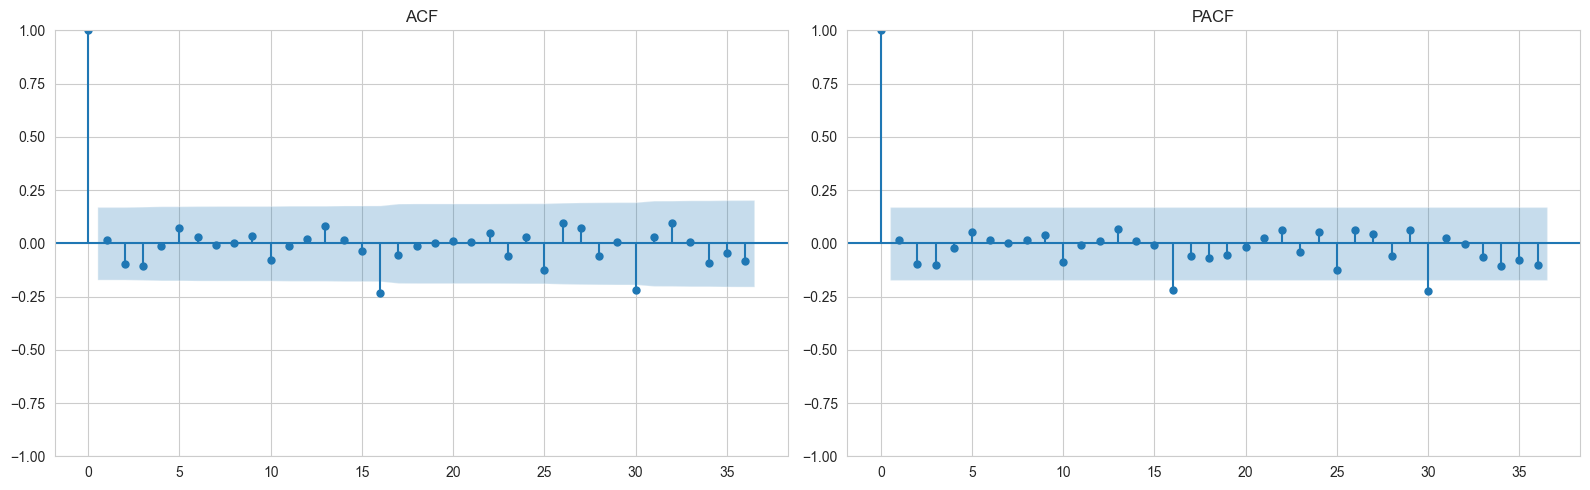

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_data.dropna(), ax=axes[0], lags=36, title='ACF')
plot_pacf(ts_data.dropna(), ax=axes[1], lags=36, title='PACF')
plt.tight_layout()
plt.show()

In [25]:
print("Running auto_arima to find best order...")
auto_model = pm.auto_arima(
    ts_data, seasonal=True, m=12,
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True,
    max_p=3, max_q=3, max_P=2, max_Q=2
)
print(f"\nBest: order={auto_model.order}, seasonal={auto_model.seasonal_order}")
print(auto_model.summary())

Running auto_arima to find best order...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=2978.044, Time=0.51 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2967.161, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2971.109, Time=0.19 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2971.266, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3616.725, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=2969.161, Time=0.03 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=2969.116, Time=0.04 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=2971.116, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2969.129, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2969.306, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=2971.165, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,0,0)[12] intercept
Total fit time: 0.996 seconds

Best: order=(0, 0, 0), seasonal=(0, 0, 0, 12)
                               SARIMAX Results        

In [26]:
train_ts = ts_data[:-12]
test_ts = ts_data[-12:]

order = auto_model.order
seasonal_order = auto_model.seasonal_order

# if auto_arima picks a trivial model, use a reasonable default
if order == (0, 0, 0) and seasonal_order[:3] == (0, 0, 0):
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 12)
    print(f'auto_arima picked trivial model, overriding with order={order}, seasonal={seasonal_order}')

fitted = SARIMAX(train_ts, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

forecast = fitted.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

mae_ts = mean_absolute_error(test_ts, forecast_mean)
rmse_ts = np.sqrt(mean_squared_error(test_ts, forecast_mean))
print(f"SARIMAX test — MAE={mae_ts:.2f}, RMSE={rmse_ts:.2f}")

auto_arima picked trivial model, overriding with order=(1, 1, 1), seasonal=(1, 1, 1, 12)
SARIMAX test — MAE=15679.90, RMSE=20292.96


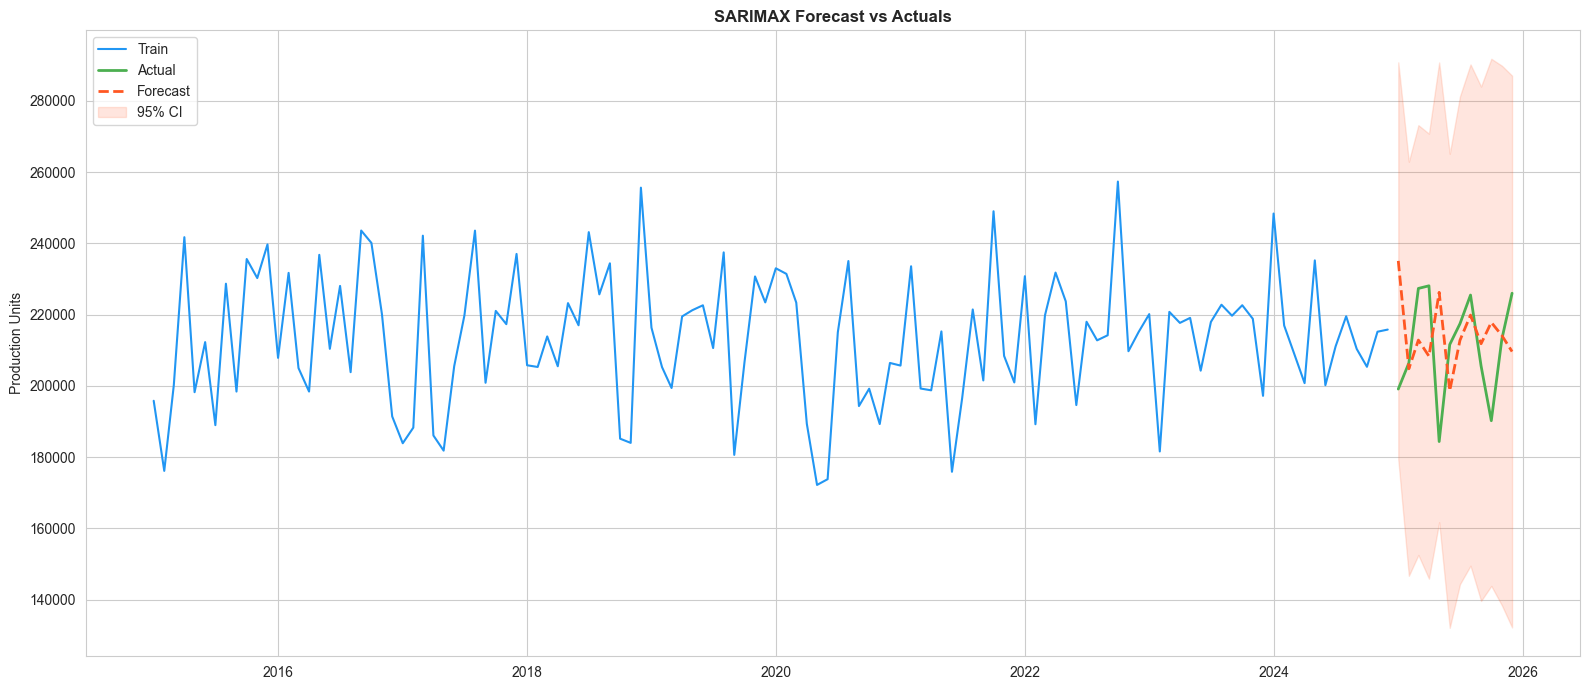

In [27]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train_ts, label='Train', color='#2196F3', linewidth=1.5)
ax.plot(test_ts, label='Actual', color='#4CAF50', linewidth=2)
ax.plot(forecast_mean, label='Forecast', color='#FF5722', linewidth=2, linestyle='--')
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='#FF5722', alpha=0.15, label='95% CI')
ax.set_title('SARIMAX Forecast vs Actuals', fontweight='bold')
ax.set_ylabel('Production Units')
ax.legend()
plt.tight_layout()
plt.show()

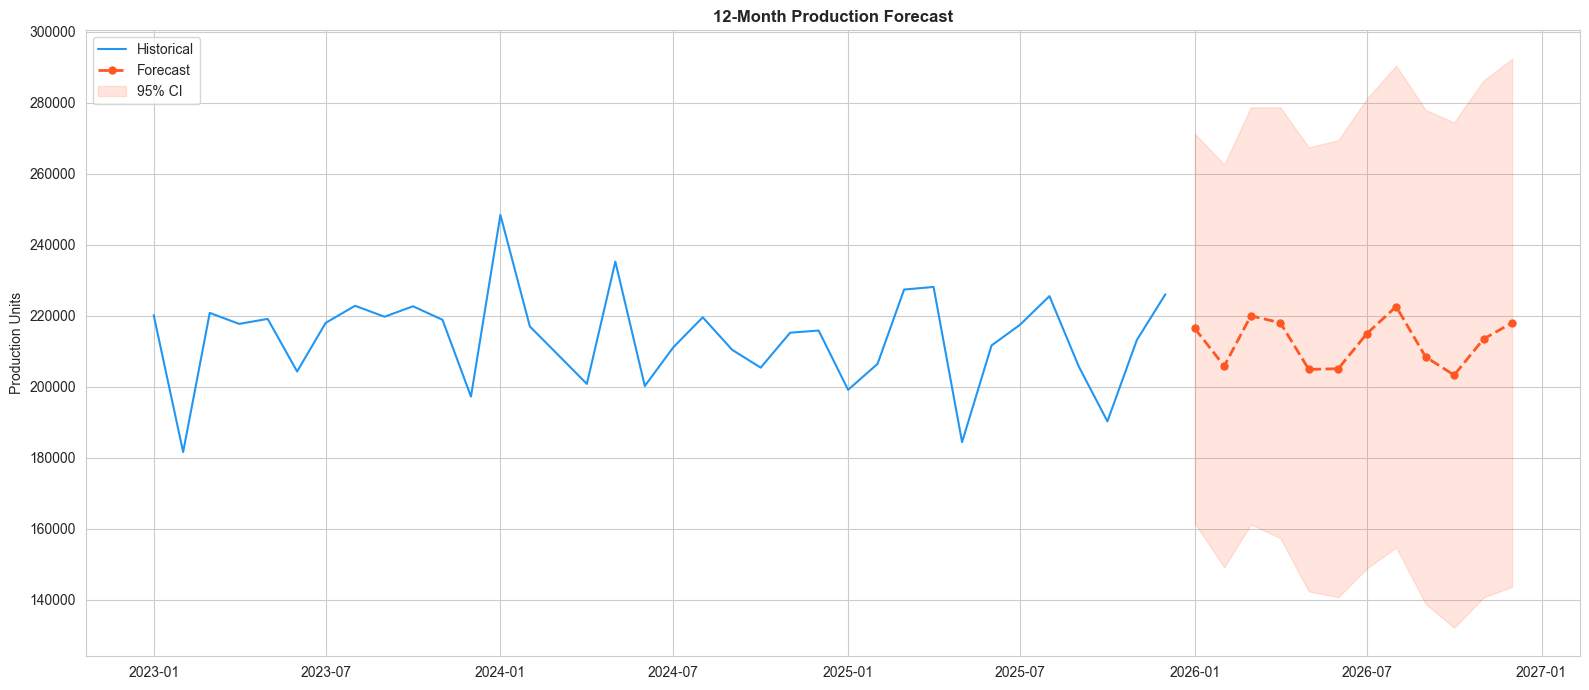

                 Forecast
2026-01-01  216356.339460
2026-02-01  205786.551507
2026-03-01  219923.587369
2026-04-01  217984.645675
2026-05-01  204839.736727
2026-06-01  205024.481327
2026-07-01  214884.613401
2026-08-01  222526.904256
2026-09-01  208350.118395
2026-10-01  203231.056073
2026-11-01  213403.093233
2026-12-01  217957.658925


In [28]:
# future 12-month forecast on full data
full_fitted = SARIMAX(ts_data, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
future = full_fitted.get_forecast(steps=12)
future_mean = future.predicted_mean
future_ci = future.conf_int()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(ts_data[-36:], label='Historical', color='#2196F3', linewidth=1.5)
ax.plot(future_mean, label='Forecast', color='#FF5722', linewidth=2, linestyle='--', marker='o', markersize=5)
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                color='#FF5722', alpha=0.15, label='95% CI')
ax.set_title('12-Month Production Forecast', fontweight='bold')
ax.set_ylabel('Production Units')
ax.legend()
plt.tight_layout()
plt.show()

print(future_mean.to_frame('Forecast').to_string())